# Vision Transformer (ViT-Tiny) - Binary Classification - 9996 Samples

This notebook trains a Vision Transformer (ViT-Tiny) model with a **single-task binary classification** head for forgery detection on driver's license images.

**Goal:** Compare binary-only performance against the multi-task model (`vit_multi_task_9996.ipynb`) to determine if dedicating full model capacity to the Real vs Fake task improves accuracy.

**Architecture:**
- **Backbone:** ViT-Tiny (pretrained on ImageNet, 192-dim embeddings)
- **Head:** Single binary classifier (Real=0, Fake=1)
- No fraud type head — all capacity focused on the binary decision

**Dataset:** Same 9,996 balanced images (50/50 Real/Fake, 3 US states: WV, DC, AZ)
- Uses the **exact same train/val/test splits** as the multi-task notebook for fair comparison

**Training:** Two-stage (frozen backbone → unfrozen fine-tuning), same hyperparameters as multi-task

**Multi-Task Baseline (to beat):**
- Binary Accuracy: 74.80%
- Combined Accuracy: 73.40%

## Setup and Data Loading

Load the existing train/val/test splits from the multi-task notebook to ensure a fair comparison. Same subject-based GroupShuffleSplit (no data leakage).

In [1]:
import os
import sys

# Fix working directory - ensure we're in the project root
project_root = "/Users/roy-siftt/final-project"
if os.path.exists(project_root):
    os.chdir(project_root)
    print(f"Changed working directory to: {os.getcwd()}")
else:
    print(f"Warning: Project root {project_root} does not exist!")
    print(f"Current directory: {os.getcwd()}")

Changed working directory to: /Users/roy-siftt/final-project


In [2]:
import pandas as pd
import os

# Load the SAME splits from the multi-task notebook (fair comparison)
data_dir = "/Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/data"

train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
val_df = pd.read_csv(os.path.join(data_dir, "val.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

print(f"Dataset loaded (same splits as multi-task notebook):")
print(f"  Train: {len(train_df)} images")
print(f"  Val:   {len(val_df)} images")
print(f"  Test:  {len(test_df)} images")

print(f"\nBinary distribution (is_fake):")
for split_name, split_df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = split_df['is_fake'].value_counts().sort_index()
    print(f"  {split_name}: Real={counts.get(0, 0)}, Fake={counts.get(1, 0)}")

print(f"\nCountry distribution (Train):")
print(train_df['source_country'].value_counts())

# Verify no leakage
train_ids = set(train_df['original_id'])
val_ids = set(val_df['original_id'])
test_ids = set(test_df['original_id'])

print(f"\nData Leakage Check:")
print(f"  Train-Val overlap: {len(train_ids & val_ids)} subjects")
print(f"  Train-Test overlap: {len(train_ids & test_ids)} subjects")
print(f"  Val-Test overlap: {len(val_ids & test_ids)} subjects")
assert len(train_ids & val_ids) == 0 and len(train_ids & test_ids) == 0 and len(val_ids & test_ids) == 0
print("  No data leakage detected!")

Dataset loaded (same splits as multi-task notebook):
  Train: 7996 images
  Val:   1000 images
  Test:  1000 images

Binary distribution (is_fake):
  Train: Real=3998, Fake=3998
  Val: Real=500, Fake=500
  Test: Real=500, Fake=500

Country distribution (Train):
source_country
DC    2698
WV    2672
AZ    2626
Name: count, dtype: int64

Data Leakage Check:
  Train-Val overlap: 0 subjects
  Train-Test overlap: 0 subjects
  Val-Test overlap: 0 subjects
  No data leakage detected!


## Binary Dataset Class

Simplified dataset class that only returns the binary label (Real=0, Fake=1). No fraud type overhead.

In [3]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import numpy as np
import cv2

class BinaryForgeryDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        img_path = os.path.join(self.root_dir, row['image_path'])
        img = Image.open(img_path).convert("RGB")
        
        # Apply transforms (Albumentations format)
        if self.transform is not None:
            if hasattr(self.transform, '__call__'):
                try:
                    img_np = np.array(img)
                    transformed = self.transform(image=img_np)
                    img = transformed['image']
                except (TypeError, KeyError):
                    img = self.transform(img)
            else:
                img = self.transform(img)

        # Binary label only
        is_fake = int(row['is_fake'])

        return img, torch.tensor(is_fake, dtype=torch.long)

## Data Augmentation and Transforms

Exact same augmentations as the multi-task notebook for fair comparison.

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Same augmentations as multi-task notebook
train_transform = A.Compose([
    A.Resize(224, 224),
    
    # Geometric transforms
    A.ShiftScaleRotate(
        shift_limit=0.08,
        scale_limit=0.12,
        rotate_limit=15,
        p=0.6
    ),
    A.Perspective(
        scale=(0.05, 0.1),
        p=0.3
    ),
    
    # Quality degradation
    A.GaussianBlur(
        blur_limit=(3, 7),
        p=0.3
    ),
    A.GaussNoise(
        std_range=(0.04, 0.12),
        mean_range=(0.0, 0.0),
        p=0.2
    ),
    A.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.05,
        p=0.4
    ),
    
    # CoarseDropout
    A.CoarseDropout(
        num_holes_range=(1, 6),
        hole_height_range=(4, 12),
        hole_width_range=(4, 12),
        fill_value=0,
        p=0.2
    ),
    
    # Normalization
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406), 
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

print("Augmentations configured (same as multi-task notebook):")
print("  - ShiftScaleRotate: shift=8%, scale=12%, rotate=15 (60% prob)")
print("  - Perspective: scale=5-10% (30% prob)")
print("  - GaussianBlur: blur_limit=3-7 (30% prob)")
print("  - GaussNoise: std_range=0.04-0.12 (20% prob)")
print("  - ColorJitter: brightness/contrast/saturation/hue (40% prob)")
print("  - CoarseDropout: 1-6 holes, size=4-12px (20% prob)")

Augmentations configured (same as multi-task notebook):
  - ShiftScaleRotate: shift=8%, scale=12%, rotate=15 (60% prob)
  - Perspective: scale=5-10% (30% prob)
  - GaussianBlur: blur_limit=3-7 (30% prob)
  - GaussNoise: std_range=0.04-0.12 (20% prob)
  - ColorJitter: brightness/contrast/saturation/hue (40% prob)
  - CoarseDropout: 1-6 holes, size=4-12px (20% prob)


/Users/roy-siftt/final-project/venv/lib/python3.13/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_9497/1256828306.py:39: UserWarning: Argument(s) 'fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


## Create DataLoaders

In [5]:
from torch.utils.data import DataLoader
import os

# Dataset root (images are in notebooks/drivers_license_forgery/vit/images/)
dataset_root = os.path.join(project_root, "notebooks/drivers_license_forgery/vit")

# Create datasets
train_dataset = BinaryForgeryDataset(train_df, dataset_root, train_transform)
val_dataset = BinaryForgeryDataset(val_df, dataset_root, val_test_transform)
test_dataset = BinaryForgeryDataset(test_df, dataset_root, val_test_transform)

# Create dataloaders (same batch size as multi-task)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=0)

print(f"Dataset sizes:")
print(f"   Train: {len(train_dataset)}")
print(f"   Val:   {len(val_dataset)}")
print(f"   Test:  {len(test_dataset)}")

# Quick sanity check
imgs, labels = next(iter(train_loader))
print(f"\nBatch shape: {imgs.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label values in batch: {labels.unique().tolist()}")

Dataset sizes:
   Train: 7996
   Val:   1000
   Test:  1000

Batch shape: torch.Size([128, 3, 224, 224])
Labels shape: torch.Size([128])
Label values in batch: [0, 1]


## Visualize Augmented Batch

Display a sample batch of augmented images to verify transforms are working correctly.

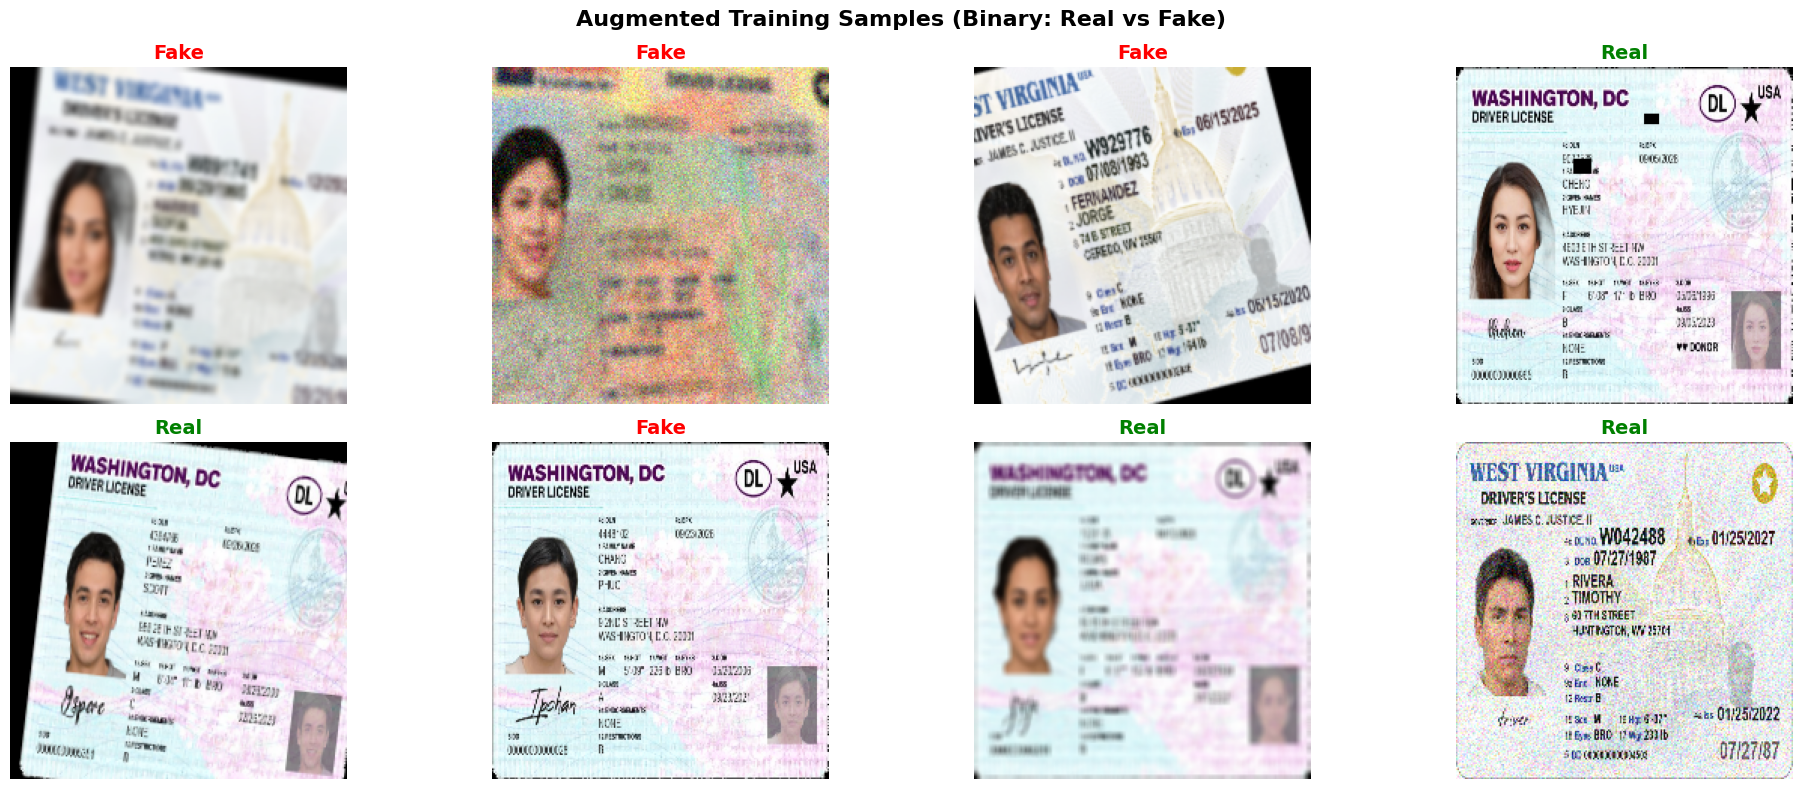

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_augmented_batch(loader, num_samples=8):
    """Display a batch of augmented images from the training loader."""
    imgs, labels = next(iter(loader))
    
    fig, axes = plt.subplots(2, num_samples // 2, figsize=(20, 8))
    axes = axes.flatten()
    
    label_names = {0: "Real", 1: "Fake"}
    
    # Denormalize for visualization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for i in range(min(num_samples, len(imgs))):
        img = imgs[i].cpu()
        img = img * std + mean
        img = img.clamp(0, 1)
        img = img.permute(1, 2, 0).numpy()
        
        label = labels[i].item()
        color = 'green' if label == 0 else 'red'
        
        axes[i].imshow(img)
        axes[i].set_title(f"{label_names[label]}", color=color, fontsize=14, fontweight='bold')
        axes[i].axis('off')
    
    plt.suptitle('Augmented Training Samples (Binary: Real vs Fake)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_augmented_batch(train_loader)

## ViT-Tiny Binary Model Definition

Single-head architecture — all model capacity focused on Real vs Fake classification.

- **Backbone:** ViT-Tiny (shared features, pretrained on ImageNet)
- **Head:** Binary Classifier (Real vs Fake) with dropout regularization

In [7]:
%pip install -q timm


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
import torch
import torch.nn as nn
import timm

class ViTBinaryClassifier(nn.Module):
    def __init__(self, num_classes=2, pretrained=True, dropout=0.25):
        super(ViTBinaryClassifier, self).__init__()
        
        # Load ViT-Tiny from timm with ImageNet pre-trained weights
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=pretrained, num_classes=0)
        
        # Feature dimension (192 for ViT-Tiny)
        num_features = self.vit.embed_dim
        
        # Single binary classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, num_classes)
        )
        
        print(f"ViT-Tiny Binary model created (pretrained={pretrained})")
        print(f"  - Feature dimension: {num_features}")
        print(f"  - Dropout: {dropout}")
        print(f"  - Output classes: {num_classes} (Real, Fake)")
        
    def forward(self, x):
        features = self.vit(x)
        return self.classifier(features)
    
    def freeze_backbone(self):
        """Freeze all parameters except the classifier head"""
        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.classifier.parameters():
            param.requires_grad = True
        print("Backbone frozen - training only classifier head")
    
    def unfreeze_backbone(self):
        """Unfreeze all parameters for full fine-tuning"""
        for param in self.parameters():
            param.requires_grad = True
        print("Backbone unfrozen - full fine-tuning enabled")

## Training Setup and Execution

**Same training strategy as multi-task notebook:**
- Stage 1: Frozen backbone, lr=1e-4, 7 epochs
- Stage 2: Unfrozen backbone, lr=1e-5, 18 epochs
- AdamW optimizer, weight_decay=0.075
- ReduceLROnPlateau scheduler
- Early stopping (patience=6)
- Label smoothing=0.075
- Gradient clipping (max_norm=1.0)

In [9]:
import torch
from torch.optim import AdamW
import torch.nn as nn
from tqdm import tqdm
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# Device
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

# ============================================
# Model Setup - ViT-Tiny Binary
# ============================================
model = ViTBinaryClassifier(num_classes=2, pretrained=True, dropout=0.25).to(device)

# Single loss function
criterion = nn.CrossEntropyLoss(label_smoothing=0.075)

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'lr': []
}

# Best model tracking
best_val_acc = 0.0
best_model_state = None
best_epoch = 0

# Settings (same as multi-task)
max_grad_norm = 1.0
early_stopping_patience = 6
min_delta = 0.005

def evaluate(loader):
    """Evaluate model on a dataset loader"""
    model.eval()
    total, correct = 0, 0
    loss_total = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss_total += loss.item()
            
            preds = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = correct / total if total > 0 else 0.0
    avg_loss = loss_total / len(loader)
    
    return {
        'acc': acc,
        'loss': avg_loss,
        'preds': all_preds,
        'labels': all_labels
    }

def train_one_epoch(train_loader, optimizer, epoch_desc):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    
    for imgs, labels in tqdm(train_loader, desc=epoch_desc):
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

# ============================================
# STAGE 1: Train with Frozen Backbone
# ============================================
print("\n" + "="*60)
print("STAGE 1: Training with Frozen Backbone")
print("="*60)
model.freeze_backbone()
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                  lr=1e-4, weight_decay=0.075)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)

stage1_epochs = 7
patience_counter = 0

for epoch in range(stage1_epochs):
    train_loss = train_one_epoch(
        train_loader, optimizer, f"Stage 1 - Epoch {epoch+1}/{stage1_epochs}"
    )
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    scheduler.step(val_metrics['loss'])
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(current_lr)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_metrics['acc']:.4f}")
    print(f"Val   Loss: {val_metrics['loss']:.4f} | Val   Acc: {val_metrics['acc']:.4f}")
    print(f"Current LR: {current_lr:.2e}")
    
    if val_metrics['acc'] > (best_val_acc + min_delta):
        best_val_acc = val_metrics['acc']
        best_epoch = epoch + 1
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"New best val acc: {best_val_acc:.4f} (epoch {best_epoch})")
    else:
        patience_counter += 1
        print(f"No improvement {patience_counter}/{early_stopping_patience}")
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered in Stage 1!")
            break

stage1_end_epoch = epoch + 1

# ============================================
# STAGE 2: Fine-Tune with Unfrozen Backbone
# ============================================
print("\n" + "="*60)
print("STAGE 2: Fine-Tuning with Unfrozen Backbone")
print("="*60)
model.unfreeze_backbone()

optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.075)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-7)

stage2_epochs = 18
patience_counter = 0

for epoch in range(stage2_epochs):
    train_loss = train_one_epoch(
        train_loader, optimizer, f"Stage 2 - Epoch {epoch+1}/{stage2_epochs}"
    )
    
    train_metrics = evaluate(train_loader)
    val_metrics = evaluate(val_loader)
    
    scheduler.step(val_metrics['loss'])
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['lr'].append(current_lr)
    
    total_epoch = stage1_end_epoch + epoch + 1
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_metrics['acc']:.4f}")
    print(f"Val   Loss: {val_metrics['loss']:.4f} | Val   Acc: {val_metrics['acc']:.4f}")
    print(f"Current LR: {current_lr:.2e} | Total Epoch: {total_epoch}")
    
    if val_metrics['acc'] > (best_val_acc + min_delta):
        best_val_acc = val_metrics['acc']
        best_epoch = total_epoch
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"New best val acc: {best_val_acc:.4f} (total epoch {best_epoch})")
    else:
        patience_counter += 1
        print(f"No improvement {patience_counter}/{early_stopping_patience}")
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered in Stage 2!")
            break

# Load best model
print("\n" + "="*60)
print("Training Complete - Loading Best Model")
print("="*60)
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model from epoch {best_epoch} (val acc: {best_val_acc:.4f})")
    print(f"\nFinal Results:")
    print(f"   - Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"   - Total Epochs Trained: {len(history['train_acc'])}")
    print(f"   - Stage 1 Epochs: {stage1_end_epoch} (Frozen Backbone)")
    print(f"   - Stage 2 Epochs: {len(history['train_acc']) - stage1_end_epoch} (Fine-Tuning)")
else:
    print("No best model found!")

Using device: mps
ViT-Tiny Binary model created (pretrained=True)
  - Feature dimension: 192
  - Dropout: 0.25
  - Output classes: 2 (Real, Fake)

STAGE 1: Training with Frozen Backbone
Backbone frozen - training only classifier head


Stage 1 - Epoch 1/7: 100%|██████████| 63/63 [02:37<00:00,  2.49s/it]


Train Loss: 1.3284 | Train Acc: 0.4826
Val   Loss: 1.1045 | Val   Acc: 0.4760
Current LR: 1.00e-04
New best val acc: 0.4760 (epoch 1)


Stage 1 - Epoch 2/7: 100%|██████████| 63/63 [02:37<00:00,  2.50s/it]


Train Loss: 1.1516 | Train Acc: 0.4849
Val   Loss: 0.9069 | Val   Acc: 0.4800
Current LR: 1.00e-04
No improvement 1/6


...

Train Loss: 0.5844 | Train Acc: 0.7021
Val   Loss: 0.5146 | Val   Acc: 0.7740
Current LR: 1.00e-05 | Total Epoch: 23
New best val acc: 0.7740 (total epoch 23)


Stage 2 - Epoch 17/18: 100%|██████████| 63/63 [03:47<00:00,  3.61s/it]


Train Loss: 0.5874 | Train Acc: 0.7052
Val   Loss: 0.4979 | Val   Acc: 0.7840
Current LR: 1.00e-05 | Total Epoch: 24
New best val acc: 0.7840 (total epoch 24)


Stage 2 - Epoch 18/18: 100%|██████████| 63/63 [03:03<00:00,  2.91s/it]


Train Loss: 0.5824 | Train Acc: 0.7205
Val   Loss: 0.4864 | Val   Acc: 0.7970
Current LR: 1.00e-05 | Total Epoch: 25
New best val acc: 0.7970 (total epoch 25)

Training Complete - Loading Best Model
Loaded best model from epoch 25 (val acc: 0.7970)

Final Results:
   - Best Validation Accuracy: 0.7970
   - Total Epochs Trained: 25
   - Stage 1 Epochs: 7 (Frozen Backbone)
   - Stage 2 Epochs: 18 (Fine-Tuning)


## Final Test Evaluation

Evaluate the best model on the test set (never seen during training).

In [10]:
# ============================================
# Final Test Evaluation
# ============================================
print("\n" + "="*60)
print("FINAL EVALUATION ON TEST SET")
print("="*60)

test_metrics = evaluate(test_loader)
print(f"\nTest Binary Accuracy: {test_metrics['acc']:.4f}")
print(f"Test Loss: {test_metrics['loss']:.4f}")

print(f"\n--- Comparison with Multi-Task Model ---")
print(f"Multi-Task Binary Accuracy: 0.7480")
print(f"Binary-Only Accuracy:       {test_metrics['acc']:.4f}")
diff = test_metrics['acc'] - 0.7480
print(f"Difference:                 {diff:+.4f} ({'better' if diff > 0 else 'worse' if diff < 0 else 'same'})")


FINAL EVALUATION ON TEST SET

Test Binary Accuracy: 0.7730
Test Loss: 0.5161

--- Comparison with Multi-Task Model ---
Multi-Task Binary Accuracy: 0.7480
Binary-Only Accuracy:       0.7730
Difference:                 +0.0250 (better)


## Training Graphs and Confusion Matrix

Visualize training curves and create confusion matrix for binary classification.

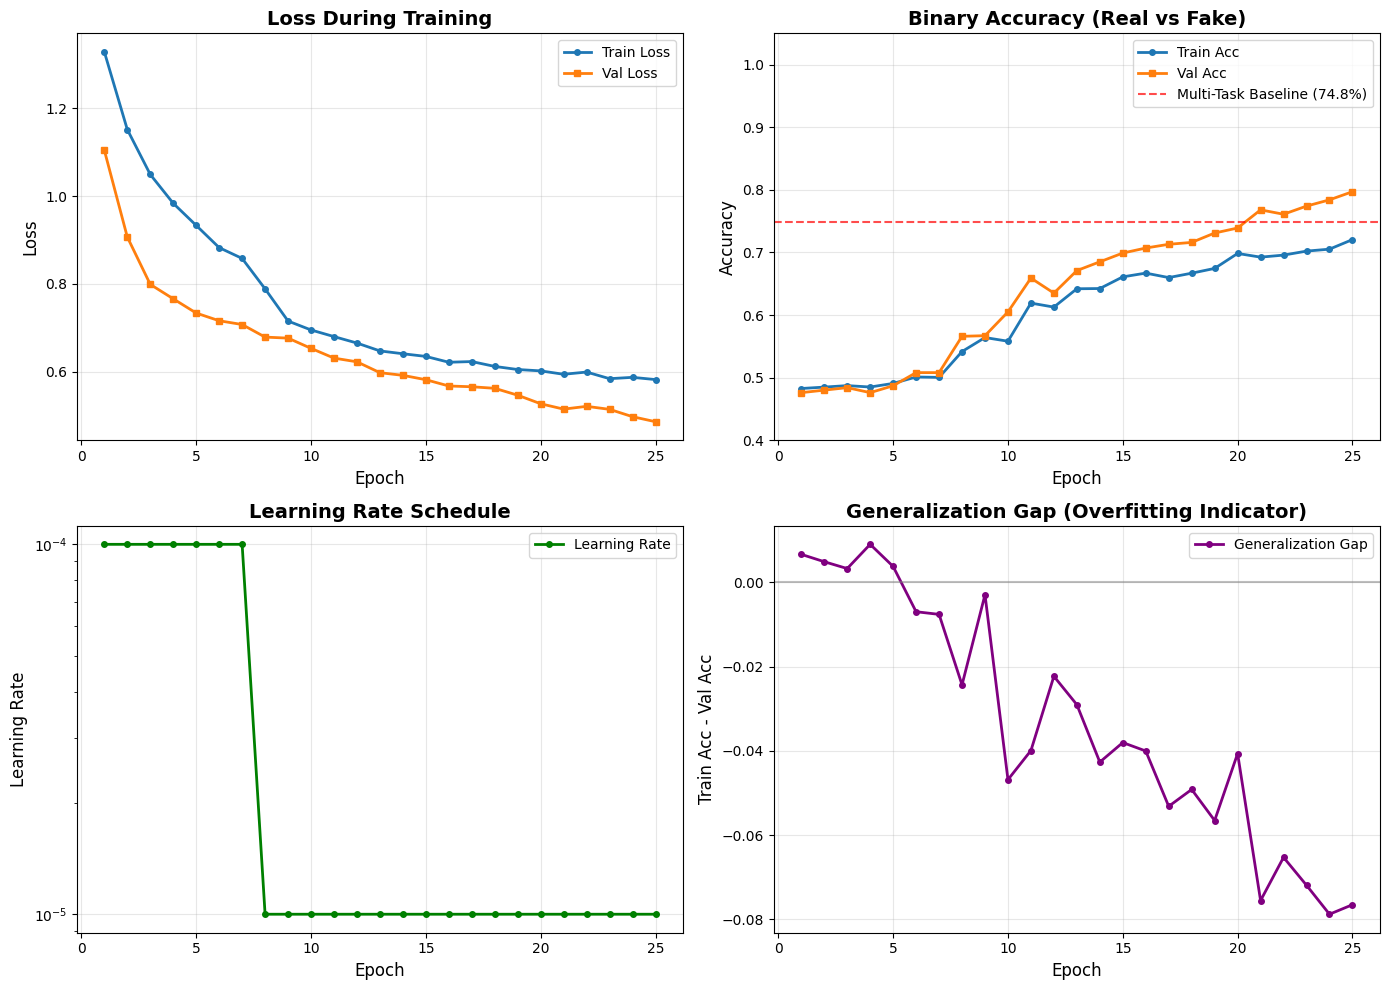


Confusion Matrix on Test Set


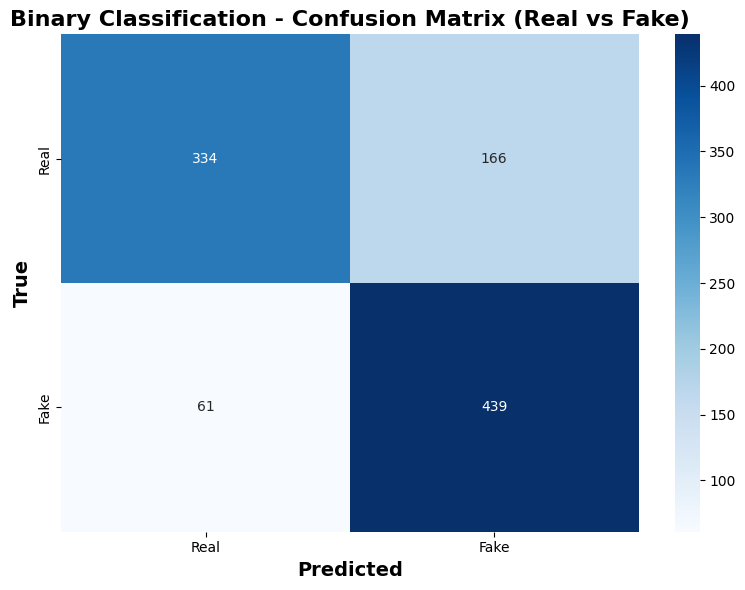


Classification Report - Binary Task
              precision    recall  f1-score   support

        Real       0.85      0.67      0.75       500
        Fake       0.73      0.88      0.79       500

    accuracy                           0.77      1000
   macro avg       0.79      0.77      0.77      1000
weighted avg       0.79      0.77      0.77      1000


Training Summary
Total Epochs Trained: 25
Best Train Accuracy: 0.7205
Best Val Accuracy: 0.7970
Best Val Accuracy Epoch: 25
Final Test Accuracy: 0.7730

--- Comparison ---
Multi-Task Binary Acc: 0.7480
Binary-Only Acc:       0.7730


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# Graph 1: Loss
axes[0, 0].plot(epochs, history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], label='Val Loss', marker='s', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Loss During Training', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# Graph 2: Binary Accuracy
axes[0, 1].plot(epochs, history['train_acc'], label='Train Acc', marker='o', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_acc'], label='Val Acc', marker='s', linewidth=2, markersize=4)
axes[0, 1].axhline(y=0.748, color='red', linestyle='--', alpha=0.7, label='Multi-Task Baseline (74.8%)')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Binary Accuracy (Real vs Fake)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.05])

# Graph 3: Learning Rate
axes[1, 0].plot(epochs, history['lr'], label='Learning Rate', marker='o', linewidth=2, markersize=4, color='green')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Learning Rate', fontsize=12)
axes[1, 0].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_yscale('log')

# Graph 4: Generalization Gap
gen_gap = [t - v for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 1].plot(epochs, gen_gap, label='Generalization Gap', marker='o', linewidth=2, markersize=4, color='purple')
axes[1, 1].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Train Acc - Val Acc', fontsize=12)
axes[1, 1].set_title('Generalization Gap (Overfitting Indicator)', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Confusion Matrix
# ============================================
print("\n" + "="*60)
print("Confusion Matrix on Test Set")
print("="*60)

# Collect predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
label_names = ['Real', 'Fake']

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=14, fontweight='bold')
ax.set_ylabel('True', fontsize=14, fontweight='bold')
ax.set_title('Binary Classification - Confusion Matrix (Real vs Fake)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification Report
print("\n" + "="*60)
print("Classification Report - Binary Task")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=label_names))

# Training Summary
print("\n" + "="*60)
print("Training Summary")
print("="*60)
print(f"Total Epochs Trained: {len(history['train_acc'])}")
print(f"Best Train Accuracy: {max(history['train_acc']):.4f}")
print(f"Best Val Accuracy: {max(history['val_acc']):.4f}")
print(f"Best Val Accuracy Epoch: {best_epoch}")
print(f"Final Test Accuracy: {test_metrics['acc']:.4f}")
print(f"\n--- Comparison ---")
print(f"Multi-Task Binary Acc: 0.7480")
print(f"Binary-Only Acc:       {test_metrics['acc']:.4f}")

## Save Model

In [12]:
import pickle

notebook_dir = "/Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit"
model_path = os.path.join(notebook_dir, "vit_binary_forgery_9996.pth")

# Save best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded best model state (epoch {best_epoch}) before saving")
    torch.save(best_model_state, model_path)
    print(f"Best model weights saved to: {model_path}")
    print(f"  (Best validation accuracy: {best_val_acc:.4f} at epoch {best_epoch})")
else:
    torch.save(model.state_dict(), model_path)
    print(f"Model weights saved to: {model_path}")

# Save label map
binary_label_map = {0: "real", 1: "fake"}
label_map_path = os.path.join(notebook_dir, "vit_binary_label_map.pkl")
with open(label_map_path, "wb") as f:
    pickle.dump(binary_label_map, f)
print(f"Label map saved to: {label_map_path}")

# Verify
if os.path.exists(model_path):
    file_size = os.path.getsize(model_path) / (1024 * 1024)
    print(f"File verified: {model_path} ({file_size:.2f} MB)")

print(f"\nLabel Mapping:")
for idx, name in binary_label_map.items():
    print(f"  {idx} -> {name}")

Loaded best model state (epoch 25) before saving
Best model weights saved to: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/vit_binary_forgery_9996.pth
  (Best validation accuracy: 0.7970 at epoch 25)
Label map saved to: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/vit_binary_label_map.pkl
File verified: /Users/roy-siftt/final-project/notebooks/drivers_license_forgery/vit/vit_binary_forgery_9996.pth (21.13 MB)

Label Mapping:
  0 -> real
  1 -> fake


## Test Model on Custom Image

Test the trained model on a single image by providing its path.

Testing model on: /Users/roy-siftt/final-project/datasets/idnet/AZ/positive/generated.photos_v3_0999206.png


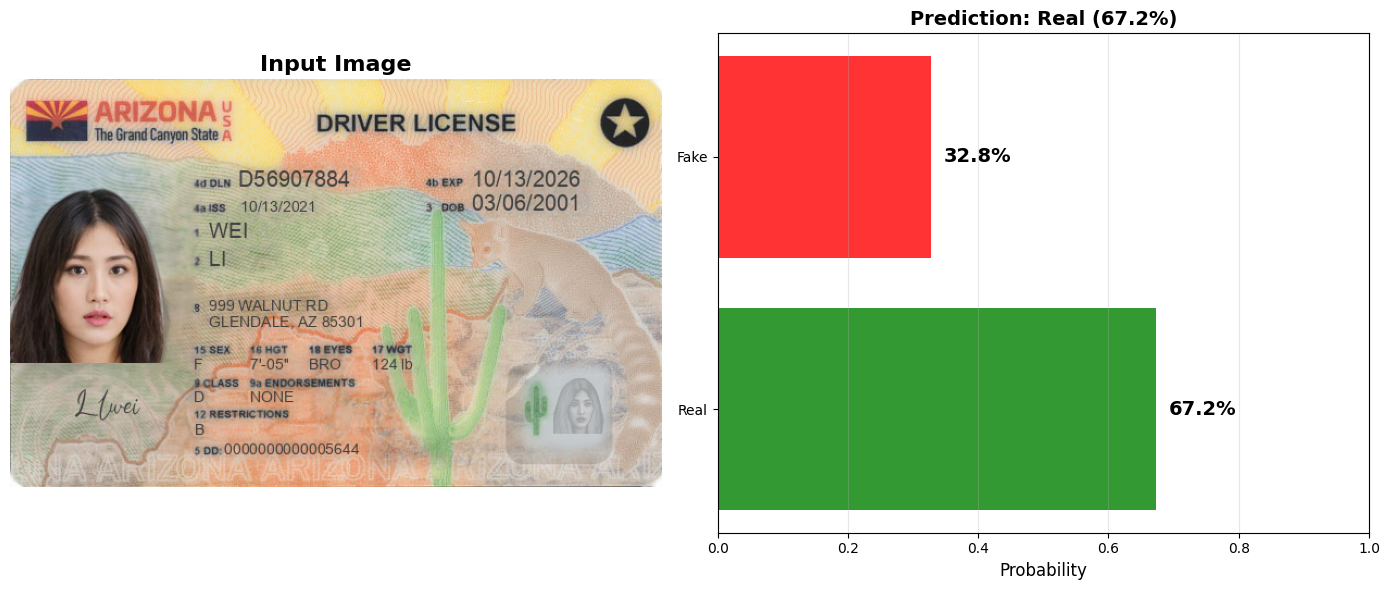


Image: /Users/roy-siftt/final-project/datasets/idnet/AZ/positive/generated.photos_v3_0999206.png
Prediction: Real
Confidence: 67.23%
Probabilities:
  > Real: 67.23%
    Fake: 32.77%


In [13]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2

def predict_image(image_path, model, device, transform=None):
    """
    Predict on a single image - binary classification (Real vs Fake).
    """
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    
    if transform is None:
        transform = A.Compose([
            A.Resize(224, 224),
            A.Normalize(
                mean=(0.485, 0.456, 0.406), 
                std=(0.229, 0.224, 0.225)
            ),
            ToTensorV2(),
        ])
    
    transformed = transform(image=img_np)
    img_tensor = transformed['image'].unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1)
        pred = torch.argmax(outputs, dim=1).item()
        confidence = probs[0][pred].item()
        
        label_names = {0: "Real", 1: "Fake"}
        
        result = {
            'prediction': label_names[pred],
            'confidence': confidence,
            'probs': {
                'Real': probs[0][0].item(),
                'Fake': probs[0][1].item()
            },
            'original_image': img
        }
        
        return result

def visualize_prediction(image_path, result):
    """
    Visualize the image with prediction.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: Original image
    axes[0].imshow(result['original_image'])
    axes[0].axis('off')
    axes[0].set_title('Input Image', fontsize=16, fontweight='bold')
    
    # Right: Prediction bar chart
    labels = list(result['probs'].keys())
    values = list(result['probs'].values())
    colors = ['green' if l == 'Real' else 'red' for l in labels]
    
    bars = axes[1].barh(labels, values, color=colors, alpha=0.8)
    axes[1].set_xlim([0, 1])
    axes[1].set_xlabel('Probability', fontsize=12)
    axes[1].set_title(f'Prediction: {result["prediction"]} ({result["confidence"]*100:.1f}%)', 
                      fontsize=14, fontweight='bold')
    
    for bar, val in zip(bars, values):
        axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2, 
                     f'{val*100:.1f}%', va='center', fontsize=14, fontweight='bold')
    
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nImage: {image_path}")
    print(f"Prediction: {result['prediction']}")
    print(f"Confidence: {result['confidence']*100:.2f}%")
    print(f"Probabilities:")
    for label, prob in result['probs'].items():
        marker = ">" if label == result['prediction'] else " "
        print(f"  {marker} {label}: {prob*100:.2f}%")

# ============================================
# Test on a single image
# ============================================
IMAGE_PATH = "/Users/roy-siftt/final-project/datasets/idnet/AZ/positive/generated.photos_v3_0999206.png"

if os.path.exists(IMAGE_PATH):
    print(f"Testing model on: {IMAGE_PATH}")
    result = predict_image(IMAGE_PATH, model, device)
    visualize_prediction(IMAGE_PATH, result)
else:
    print(f"Image not found: {IMAGE_PATH}")
    print("Set IMAGE_PATH to a valid image path and re-run.")

## Evaluation on Random Samples

Test the model on randomly selected images from the test set and display results with per-class breakdown.

In [15]:
import random
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Sample random images from test set
num_samples = 100
sample_df = test_df.sample(n=min(num_samples, len(test_df)), random_state=42)

print(f"Evaluating on {len(sample_df)} random test samples...")
print(f"  Real: {(sample_df['is_fake'] == 0).sum()}")
print(f"  Fake: {(sample_df['is_fake'] == 1).sum()}")

results = []
correct = 0
total = 0

dataset_root = os.path.join(project_root, "notebooks/drivers_license_forgery/vit")

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Evaluating"):
    img_path = os.path.join(dataset_root, row['image_path'])
    if not os.path.exists(img_path):
        continue
    
    result = predict_image(img_path, model, device)
    true_label = "Fake" if row['is_fake'] == 1 else "Real"
    pred_label = result['prediction']
    is_correct = (pred_label == true_label)
    
    results.append({
        'image': row['image_path'],
        'true_label': true_label,
        'predicted': pred_label,
        'confidence': result['confidence'],
        'correct': is_correct
    })
    
    total += 1
    if is_correct:
        correct += 1

accuracy = correct / total if total > 0 else 0
print(f"\nRandom Sample Results:")
print(f"  Accuracy: {accuracy:.4f} ({correct}/{total})")

# Per-class breakdown
results_df = pd.DataFrame(results)
for label in ['Real', 'Fake']:
    subset = results_df[results_df['true_label'] == label]
    if len(subset) > 0:
        acc = subset['correct'].mean()
        avg_conf = subset['confidence'].mean()
        print(f"  {label}: {acc:.4f} accuracy, {avg_conf:.4f} avg confidence ({len(subset)} samples)")

# Show some wrong predictions
wrong = results_df[results_df['correct'] == False]
if len(wrong) > 0:
    print(f"\nMisclassified samples ({len(wrong)}/{total}):")
    for _, row in wrong.head(10).iterrows():
        print(f"  {row['image']}: true={row['true_label']}, pred={row['predicted']} ({row['confidence']*100:.1f}%)")

Evaluating on 100 random test samples...
  Real: 50
  Fake: 50


Evaluating: 100%|██████████| 100/100 [00:02<00:00, 33.57it/s]


Random Sample Results:
  Accuracy: 0.7000 (70/100)
  Real: 0.6000 accuracy, 0.6957 avg confidence (50 samples)
  Fake: 0.8000 accuracy, 0.7767 avg confidence (50 samples)

Misclassified samples (30/100):
  images/face_replacement_DC_0677368.png: true=Fake, pred=Real (74.5%)
  images/face_morphing_AZ_0598044.png: true=Fake, pred=Real (53.5%)
  images/face_morphing_AZ_0976160.png: true=Fake, pred=Real (55.9%)
  images/real_AZ_0730005.png: true=Real, pred=Fake (57.0%)
  images/face_replacement_AZ_0956520.png: true=Fake, pred=Real (55.6%)
  images/real_WV_0315279.png: true=Real, pred=Fake (56.9%)
  images/face_morphing_DC_0075935.png: true=Fake, pred=Real (73.0%)
  images/real_AZ_0579999.png: true=Real, pred=Fake (50.0%)
  images/real_AZ_0941809.png: true=Real, pred=Fake (81.1%)
  images/real_DC_0461490.png: true=Real, pred=Fake (59.3%)
